# XGBoost Classification

This notebook will use the XGBoost classification models, integrated with scikit-learn, to perform win/loss classification on our data. Again, we are comparing the performance on the three different datasets.

## 1. Handling Packages and Data

We begin will all of the imports and data preprocessing.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import log_loss
from utils import *

In [2]:
df_full = pd.read_csv("../Data/full_data_enc.csv")
df_nodds = pd.read_csv("../Data/nodds_data_enc.csv")
df_odds = pd.read_csv("../Data/odds_data_enc.csv")

In [3]:
df_full_train, df_full_test = chrono_split_df(df_full, threshold=0.8)
df_nodds_train, df_nodds_test = chrono_split_df(df_nodds, threshold=0.8)
df_odds_train, df_odds_test = chrono_split_df(df_odds, threshold=0.8)

In [4]:
X_train_full, y_train = np.array(df_full_train.drop(columns="dj_win")), np.array(
    df_full_train["dj_win"])
X_train_nodds = np.array(df_nodds_train.drop(columns="dj_win"))
X_train_odds = np.array(df_odds_train.drop(columns="dj_win"))

X_test_full, y_test = np.array(df_full_test.drop(columns="dj_win")), np.array(
    df_full_test["dj_win"])
X_test_nodds = np.array(df_nodds_test.drop(columns="dj_win"))
X_test_odds = np.array(df_odds_test.drop(columns="dj_win"))

## 2. Hyperparameter Search

XGBoost has many tunable hyperparameters. We will now develop a pipeline that we can apply to any of our datasets to tune an XGBoost classifier. We already have an expanding window fold-making function in our utils.py file. We will first define a cross-validation loop that will find the average log-loss across the folds for the current parameter combination, as well as the best iteration (number of trees) that achieved the lowest validation log-loss.

In [5]:
def cv_score(params, X, y, n_splits=5):

    """
        Function to calculate the performance of an XGBoost classifier across an expanding window
        fold set. Returns the average loss, standard deviation of losses, and the average number
        of trees for which the ensemble model had the best validation performance.
    """

    losses = [] 
    best_iterations = []

    for train_fold, val_fold in expanding_folds(X.shape[0], n_splits=n_splits):
        model = XGBClassifier(**params, n_estimators=2000, early_stopping_rounds=50, 
                              eval_metric="logloss", tree_method="hist")
        model.fit(X[train_fold], y[train_fold], eval_set=[(X[val_fold], y[val_fold])], verbose=False)
        best_loss = log_loss(y[val_fold], model.predict_proba(X[val_fold])[:, 1])
        losses.append(best_loss)
        best_iterations.append(model.best_iteration + 1)

    return np.mean(losses), np.std(losses), int(np.mean(best_iterations))

Now, we will define a function that will give us a random sample of parameters for our random grid search. [EXPLAIN WHY RANDOM BETTER THAN GRID SEARCH]. Then we will generate the sample of parameters that we will use for our hyperparameter search. It is important that we use the exact same parameters for each of the models, so that the results are comparable, and no model has an unfair advantage by getting lucky with its parameter generations.

In [6]:
def sample_params(rng):

    """
        Returns a sample of parameters for the random grid search.
    """

    params = {
        "learning_rate" : 0.05,
        "max_depth" : rng.integers(2, 6),
        "min_child_weight" : float(np.exp(rng.uniform(np.log(1), np.log(20)))),
        "subsample" : float(rng.uniform(0.6, 1.0)),
        "colsample_bytree": float(rng.uniform(0.5, 1.0)),
        "reg_lambda": float(np.exp(rng.uniform(np.log(0.1), np.log(20)))),
    }

    return params

In [7]:
rng = np.random.default_rng(42)
params_list = [sample_params(rng) for _ in range(40)]

In [8]:
results = []

for name, data in {"Full" : X_train_full, "No Odds" : X_train_nodds, "Odds Only" : X_train_odds}.items():
    for i, params in enumerate(params_list):
        mean_loss, std_losses, best_iteration = cv_score(params, data, y_train)
        results.append({"Data" : name, "Config" : i, **params, "Mean" : mean_loss,
                        "Deviation" : std_losses, "Best_Ensemble_Size" : best_iteration})

results_frame = pd.DataFrame(results)

In [9]:
best_params = results_frame.loc[results_frame.groupby("Data")["Mean"].idxmin()]
best_params

,Data,Config,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,Mean,Deviation,Best_Ensemble_Size
12,Full,12,0.05,3,10.369358,0.783566,0.784371,0.209738,0.347291,0.052648,79
71,No Odds,31,0.05,2,4.296918,0.796283,0.968913,2.068061,0.366018,0.047316,60
86,Odds Only,6,0.05,3,1.587579,0.873220,0.872381,16.837163,0.337244,0.065816,351


As we can see, each dataset-specific model performed best using a different configuration. In particular, the average best ensemble size is much larger for the odds only model than the other two models. This indicates that adding further trees kept decreasing the validation loss in the Odds Only model for much longer than in the other two models. This is because of the lower-dimensional feature space meaning less clear separations are available and so more trees are required for effective feature space partitioning. Now, we will use each of these configurations to train the models on the entire training set.

# 3. Training and Evaluation

We will now train each of the dataset-specific models using the configuration that achieved the lowest average validation loss over the expanding window folds, before evaluating their performance on our test set. We no longer need to use early stopping since this was only required in training to prevent unnecessary iterations when we are no longer improving the validation loss. Now that we have an ideal average iteration depth (number of trees) for each dataset, we just use that as our hyperparameter, and no longer have a variable number of trees depending on the early stopping criterion.

In [10]:
def model_fitter(data_string, X_train, y_train):

    """
        Fits an XGBoost Classifier to the specified dataset using the best parameters found by our
        hyperparameter search.
    """

    best_config = np.array(best_params.loc[best_params["Data"] == data_string]["Config"])

    params = params_list[best_config.squeeze()]

    model = XGBClassifier(**params, n_estimators=np.array(best_params.loc[best_params["Data"] == data_string]
                          ["Best_Ensemble_Size"]).squeeze(), tree_method="hist")
    model.fit(X_train, y_train)

    return model

In [12]:
full_model = model_fitter("Full", X_train_full, y_train)
nodds_model = model_fitter("No Odds", X_train_nodds, y_train)
odds_model = model_fitter("Odds Only", X_train_odds, y_train)

We have now fitted each model with the ideal hyperparameters. Next, we evaluate the performance of each model on the test set, checking the accuracy, log-loss, precision and recall of each model.

In [13]:
def confusion_matrix(y_pred, y):

    """
        Forms the confusion matrix given an array of label predictions (y_pred) and true labels (y).
    """

    aa = np.sum((y_pred == 1) & (y == 1))
    ab = np.sum((y_pred == 1) & (y == 0))
    ba = np.sum((y_pred == 0) & (y == 1))
    bb = np.sum((y_pred == 0) & (y == 0))

    return np.array([[aa, ab], 
                    [ba, bb]])

In [18]:
def performance_analysis(model, X_test, y_test):

    """
        Does a performance analysis on for the specified model on the test set.
    """

    probs = model.predict_proba(X_test)[:, 1]
    y_pred = (probs >= 0.5).astype(float)
    bce = log_loss(y_test, probs)
    acc = np.mean((y_pred == y_test).astype(float))

    mat = confusion_matrix(y_pred, y_test)
    positive_precision = mat[0, 0] / (mat[0, 0] + mat[0, 1]) if (mat[0, 0] + mat[0, 1]) else 0.0
    positive_recall = mat[0, 0] / (mat[0, 0] + mat[1, 0]) if (mat[0, 0] + mat[1, 0]) else 0.0
    negative_precision = mat[1, 1] / (mat[1, 0] + mat[1, 1]) if (mat[1, 0] + mat[1, 1]) else 0.0
    negative_recall = mat[1, 1] / (mat[1, 1] + mat[0, 1]) if (mat[1, 1] + mat[0, 1]) else 0.0

    print("-" * 30)
    print(f"Confusion matrix:")
    print(mat)
    print(f"Positive Precision: {positive_precision :.4f}")
    print(f"Negative Precision: {negative_precision :.4f}")
    print(f"Positive Recall: {positive_recall:.4f}")
    print(f"Negative Recall: {negative_recall:.4f}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Binary Cross-Entropy: {bce:.4f}")

In [19]:
print("Full Dataset Model Evaluation:")
performance_analysis(full_model, X_test_full, y_test)

Full Dataset Model Evaluation:
------------------------------
Confusion matrix:
[[204  33]
 [  4   7]]
Positive Precision: 0.8608
Negative Precision: 0.6364
Positive Recall: 0.9808
Negative Recall: 0.1750
Accuracy: 85.08%
Binary Cross-Entropy: 0.3733


In [20]:
print("No Odds Dataset Model Evaluation:")
performance_analysis(nodds_model, X_test_nodds, y_test)

No Odds Dataset Model Evaluation:
------------------------------
Confusion matrix:
[[205  38]
 [  3   2]]
Positive Precision: 0.8436
Negative Precision: 0.4000
Positive Recall: 0.9856
Negative Recall: 0.0500
Accuracy: 83.47%
Binary Cross-Entropy: 0.4113


In [21]:
print("Odds Only Dataset Model Evaluation:")
performance_analysis(odds_model, X_test_odds, y_test)

Odds Only Dataset Model Evaluation:
------------------------------
Confusion matrix:
[[206  36]
 [  2   4]]
Positive Precision: 0.8512
Negative Precision: 0.6667
Positive Recall: 0.9904
Negative Recall: 0.1000
Accuracy: 84.68%
Binary Cross-Entropy: 0.3656


The performance is similar to what we saw in our other models. The no odds model has the worst performance, achieving an accuracy of $\approx 82.47%$ and a binary cross-entropy of $0.4113$. The full model and odds only model have interestingly contrasting behaviour. The binary cross-entropy for the odds only model is $0.3656$ compared to a binary cross-entropy of $0.3733$ for the full model. This indicates a better calibration of the prediction probabilities for the odds only model, with more confidently correct label probabilities. However, the accuracy for the odds only model is $84.68%$ compared to $85.08%$ for the full model. This indicates that, although the probabilities are better calibrated in the odds only model, the full model's probabilities are more often on the correct side of $0.5$. This accuracy and binary cross-entropy discrepancy can happen if the model with the higher accuracy's probability predictions are more frequently on the correct side of $0.5$, but less confidently so than the other model. This could also happen if the full model on average has more correct predictions, but has a few overconfidently wrong predictions compared to the other model that increase its binary cross-entropy. Overall, these findings are not contradicting each other.

# 4. Model Calibration

First, comparing the probability error residuals of the full model vs the odds only model will help us understand the accuracy and log-loss behaviour we observed.

In [32]:
def residual_check(model, X_test, y_test):

    """
        Analysis of the residuals (true label minus probabilities) to understand the confidence of
        the model, and how often it is overconfidently wrong.
    """

    model.fit(X_test, y_test)
    probs = model.predict_proba(X_test)[:, 1]
    resids = np.abs(y_test - probs)

    return resids, np.mean(resids)

In [33]:
resids_full, mean_resid_full = residual_check(full_model, X_test_full, y_test)
resids_odds, mean_resids_odds = residual_check(odds_model, X_test_odds, y_test)

In [34]:
print(f"Error residual of full model: {mean_resid_full:.4f}")
print(f"Error residual of odds model: {mean_resids_odds:.4f}")

Error residual of full model: 0.2357
Error residual of odds model: 0.2115


This begins to explain our findings. We can see that the error residual of the full model is higher than for the odds model, indicating that the assigned probabilities are less confident in their predictions in the full model. This is because a high residual means that the gap between the true label ($0$/$1$) and the assigned probabilities is larger on average, so the assigned probabilities are less close to the true labels, i.e. less confident.

Let us now also provide some calibration plots of the full and odds-only model. This separates the predicted probabilities into bins, and then compares the mean probability of each bin with the actual win rate that was observed in this bin.

In [46]:
def calibration_plot(model, X_test, y_test):

    """
        Gives a calibration plot for the specified model and test set.
    """

    probs = model.predict_proba(X_test)[:, 1]
    df = pd.DataFrame({"probs": probs, "y": y_test})
    df_sorted = df.sort_values("probs")

    for split in np.array_split(df_sorted, 8):
        true_mean = np.mean(split[:, 1])
        true_se = np.sqrt(true_mean * (1 - true_mean) / split.shape[0])
        avg_bin_pred = np.mean(split[:, 0])

    fig, ax = plt.subplots(1, figsize=(14, 8))
    ax.plot(avg_bin_pred, true_mean)
    ax.plot(np.linspace(0, 1), np.linspace(0, 1))
    ax.set_title(f"Calibration Plot for {model}")
    ax.set_xlabel("Average Bin Prediction")
    ax.set_ylabel("True Bin Win Rate")  
    plt.show()




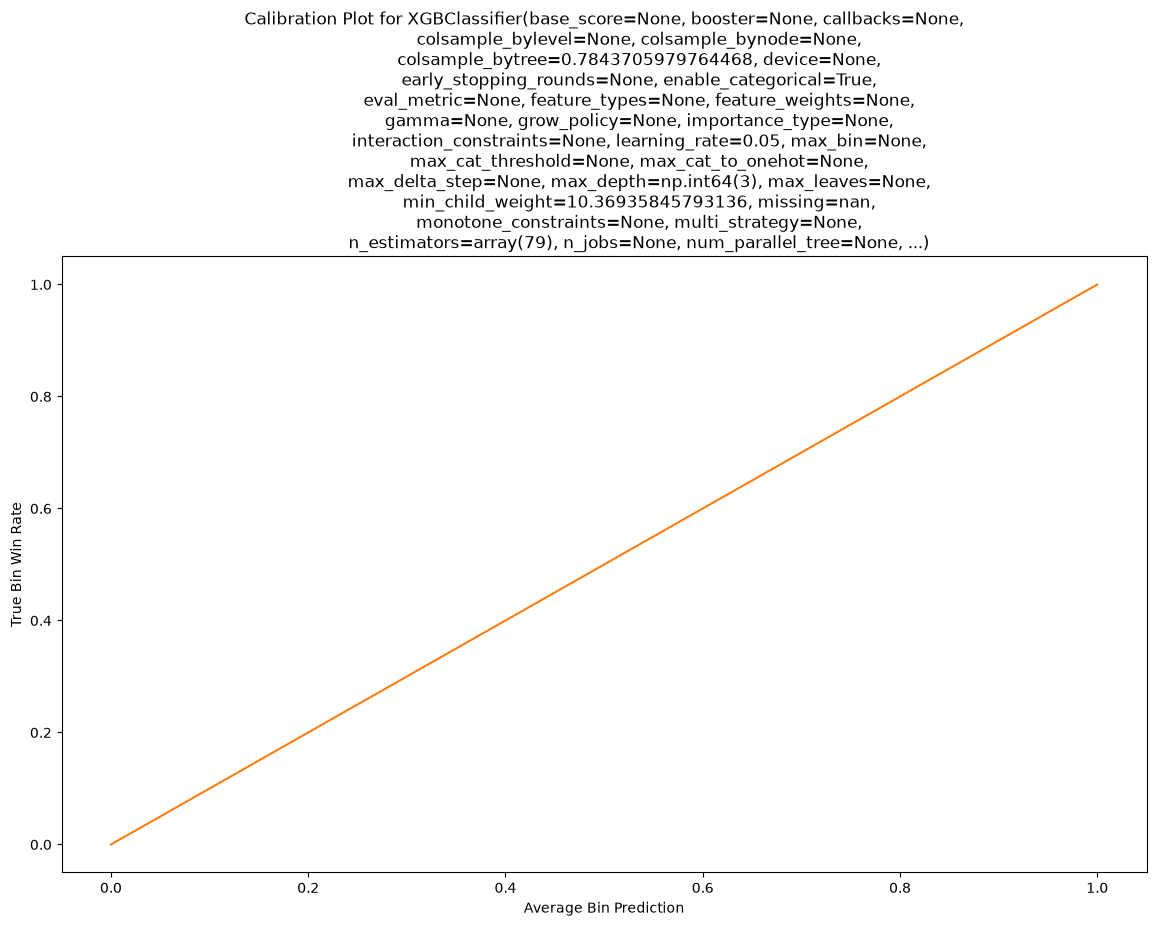

In [47]:
calibration_plot(full_model, X_test_full, y_test)